In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Portfolio weights from Module 2 – Risk Parity optimization
tickers = {
    'RHM.DE': 'Rheinmetall',
    'ENR.DE': 'Siemens Energy',
    'SAP.DE': 'SAP',
    'AIR.DE': 'Airbus',
    'SIE.DE': 'Siemens',
    'DTE.DE': 'Deutsche Telekom',
    'MUV2.DE': 'Munich Re',
    'ADS.DE': 'Adidas'
}

# Optimized weights from Risk Parity – Module 2 output
weights = np.array([0.103, 0.109, 0.221, 0.071, 0.153, 0.111, 0.129, 0.102])

os.makedirs('data', exist_ok=True)
print("Libraries loaded")

Libraries loaded


In [2]:
raw = yf.download(
    list(tickers.keys()),
    start='2022-01-01',
    end='2026-03-01',
    progress=False
)['Close']

raw.columns = [tickers[t] for t in raw.columns]
raw = raw.dropna(thresh=len(tickers) - 2).ffill()

# Download DAX benchmark for comparison
dax_raw = yf.download('^GDAXI', start='2022-01-01',
                      end='2026-03-01', progress=False)['Close']

returns = np.log(raw / raw.shift(1)).dropna()

# Portfolio daily returns using Risk Parity weights
port_returns = returns @ weights

# Annualized stats
mean_daily   = port_returns.mean()
std_daily    = port_returns.std()
ann_return   = mean_daily * 252
ann_vol      = std_daily * np.sqrt(252)

print(f"Portfolio – Annualized Return:    {ann_return:.2%}")
print(f"Portfolio – Annualized Volatility: {ann_vol:.2%}")
print(f"Portfolio – Sharpe Ratio:          {(ann_return - 0.025) / ann_vol:.2f}")

Portfolio – Annualized Return:    21.98%
Portfolio – Annualized Volatility: 17.28%
Portfolio – Sharpe Ratio:          1.13


In [3]:
np.random.seed(42)

n_simulations = 10_000
n_days        = 252  # 1 trading year forward

# Simulate using historical mean and std of portfolio daily returns
simulations = np.zeros((n_days, n_simulations))

for i in range(n_simulations):
    daily_shocks = np.random.normal(mean_daily, std_daily, n_days)
    simulations[:, i] = np.cumprod(1 + daily_shocks)

# Final portfolio values after 1 year (starting from 1.0)
final_values = simulations[-1, :]

print(f"Monte Carlo Simulation – 10,000 scenarios over 1 trading year\n")
print(f"  Median outcome:       {np.percentile(final_values, 50):.2%} total return")
print(f"  Best 5% scenario:     {np.percentile(final_values, 95):.2%} total return")
print(f"  Worst 5% scenario:    {np.percentile(final_values, 5):.2%} total return")
print(f"  Probability of loss:  {(final_values < 1.0).mean():.1%}")

Monte Carlo Simulation – 10,000 scenarios over 1 trading year

  Median outcome:       122.56% total return
  Best 5% scenario:     162.31% total return
  Worst 5% scenario:    92.01% total return
  Probability of loss:  11.7%


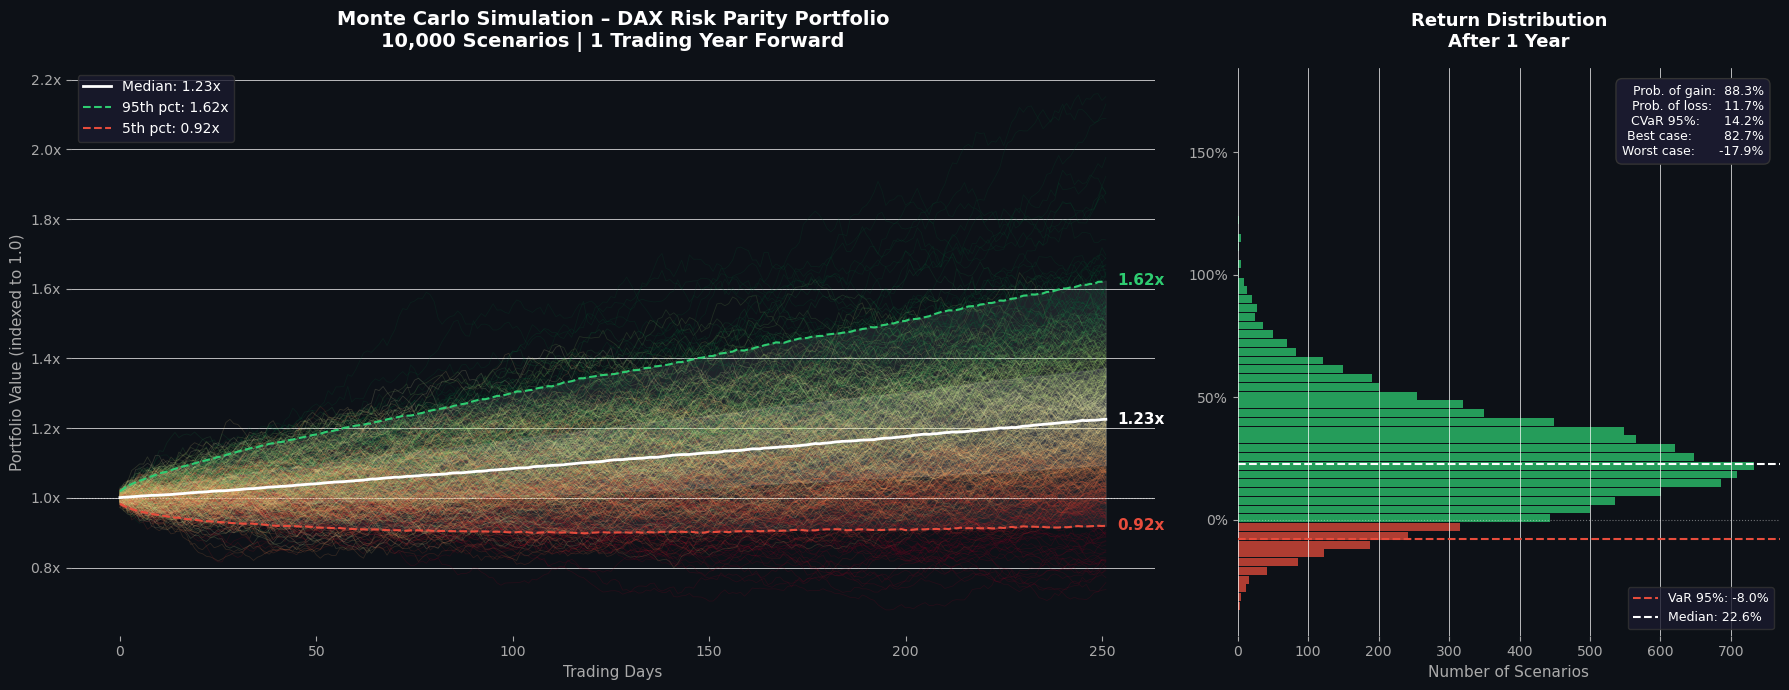

Saved to data/03_monte_carlo_paths.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7),
                                gridspec_kw={'width_ratios': [2, 1]})
fig.patch.set_facecolor('#0d1117')
ax1.set_facecolor('#0d1117')
ax2.set_facecolor('#0d1117')

# ── Left: Simulation paths ────────────────────────────────────────────────────
# Color paths by final value – green = good outcome, red = bad outcome
sample_idx   = np.random.choice(n_simulations, 500, replace=False)
final_sample = simulations[-1, sample_idx]
norm         = plt.Normalize(vmin=np.percentile(final_sample, 5),
                             vmax=np.percentile(final_sample, 95))
cmap         = plt.cm.RdYlGn

for i, idx in enumerate(sample_idx):
    color = cmap(norm(simulations[-1, idx]))
    ax1.plot(simulations[:, idx], color=color, alpha=0.15, linewidth=0.6)

# Percentile bands
p5  = np.percentile(simulations, 5,  axis=1)
p25 = np.percentile(simulations, 25, axis=1)
p50 = np.percentile(simulations, 50, axis=1)
p75 = np.percentile(simulations, 75, axis=1)
p95 = np.percentile(simulations, 95, axis=1)

ax1.fill_between(range(n_days), p5,  p95,  alpha=0.08, color='white')
ax1.fill_between(range(n_days), p25, p75,  alpha=0.12, color='white')
ax1.plot(p50, color='white',   linewidth=2.0, zorder=5,
         label=f'Median: {p50[-1]:.2f}x')
ax1.plot(p95, color='#2ecc71', linewidth=1.5, linestyle='--', zorder=5,
         label=f'95th pct: {p95[-1]:.2f}x')
ax1.plot(p5,  color='#e74c3c', linewidth=1.5, linestyle='--', zorder=5,
         label=f'5th pct: {p5[-1]:.2f}x')
ax1.axhline(1.0, color='white', linewidth=0.8, linestyle=':', alpha=0.4)

# End annotations
for val, col in [(p50[-1], 'white'), (p95[-1], '#2ecc71'), (p5[-1], '#e74c3c')]:
    ax1.annotate(f'{val:.2f}x',
                 xy=(n_days - 1, val),
                 xytext=(n_days + 2, val),
                 color=col, fontsize=11,
                 fontweight='bold', va='center')

ax1.set_title('Monte Carlo Simulation – DAX Risk Parity Portfolio\n'
              '10,000 Scenarios | 1 Trading Year Forward',
              fontsize=14, fontweight='bold', color='white', pad=15)
ax1.set_xlabel('Trading Days', fontsize=11, color='#aaaaaa')
ax1.set_ylabel('Portfolio Value (indexed to 1.0)', fontsize=11, color='#aaaaaa')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}x'))
ax1.tick_params(colors='#aaaaaa')
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.grid(axis='y', color='#ffffff15', linewidth=0.5)
ax1.legend(fontsize=10, loc='upper left',
           facecolor='#1a1a2e', edgecolor='#333333', labelcolor='white')

# ── Right: Return distribution histogram ─────────────────────────────────────
final_returns = final_values - 1
bins          = np.linspace(final_returns.min(), final_returns.max(), 60)

# Color bins by return zone
for i in range(len(bins) - 1):
    mask  = (final_returns >= bins[i]) & (final_returns < bins[i+1])
    count = mask.sum()
    mid   = (bins[i] + bins[i+1]) / 2
    color = '#e74c3c' if mid < 0 else '#2ecc71'
    ax2.barh(mid, count, height=(bins[1] - bins[0]) * 0.9,
             color=color, alpha=0.75, edgecolor='none')

# VaR and median lines
ax2.axhline(var_95,                      color='#e74c3c', linewidth=1.5,
            linestyle='--', label=f'VaR 95%: {var_95:.1%}')
ax2.axhline(np.median(final_returns),    color='white',   linewidth=1.5,
            linestyle='--', label=f'Median: {np.median(final_returns):.1%}')
ax2.axhline(0, color='white', linewidth=0.8, linestyle=':', alpha=0.4)

ax2.set_title('Return Distribution\nAfter 1 Year',
              fontsize=13, fontweight='bold', color='white', pad=15)
ax2.set_xlabel('Number of Scenarios', fontsize=11, color='#aaaaaa')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax2.tick_params(colors='#aaaaaa')
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.grid(axis='x', color='#ffffff15', linewidth=0.5)
ax2.legend(fontsize=9, loc='lower right',
           facecolor='#1a1a2e', edgecolor='#333333', labelcolor='white')

# Stats box
stats_text = (f"Prob. of gain:  {(final_values > 1.0).mean():.1%}\n"
              f"Prob. of loss:   {(final_values < 1.0).mean():.1%}\n"
              f"CVaR 95%:      {abs(cvar_95):.1%}\n"
              f"Best case:        {np.percentile(final_returns, 99):.1%}\n"
              f"Worst case:      {np.percentile(final_returns, 1):.1%}")

ax2.text(0.97, 0.97, stats_text,
         transform=ax2.transAxes,
         fontsize=9, color='white', va='top', ha='right',
         bbox=dict(facecolor='#1a1a2e', edgecolor='#333333',
                   boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.savefig('data/03_monte_carlo_paths.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved to data/03_monte_carlo_paths.png")

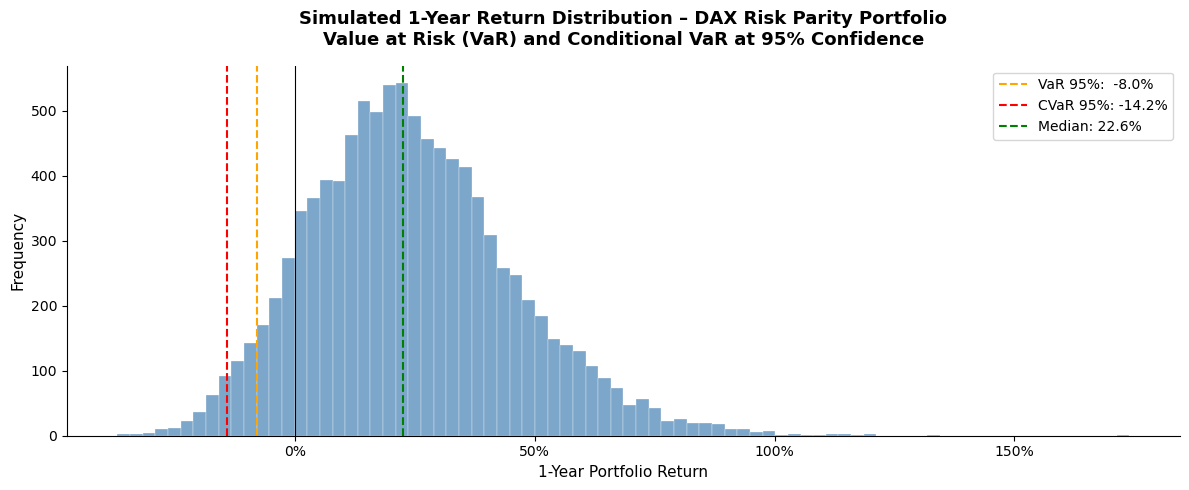


Risk Summary:
  VaR  95%: In worst 5% of scenarios, loss exceeds 8.0%
  CVaR 95%: Average loss in worst 5% of scenarios: 14.2%
  Probability of loss: 11.7%


In [5]:
rf = 0.025

# VaR and CVaR at 95% confidence level
var_95  = np.percentile(final_values - 1, 5)
cvar_95 = (final_values - 1)[final_values - 1 <= var_95].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(final_values - 1, bins=80, color='steelblue',
        alpha=0.7, edgecolor='white', linewidth=0.3)

# VaR and CVaR lines
ax.axvline(var_95,  color='orange', linewidth=1.5, linestyle='--',
           label=f'VaR 95%:  {var_95:.1%}')
ax.axvline(cvar_95, color='red',    linewidth=1.5, linestyle='--',
           label=f'CVaR 95%: {cvar_95:.1%}')
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')

# Median and expected return
ax.axvline(np.median(final_values - 1), color='green', linewidth=1.5,
           linestyle='--',
           label=f'Median: {np.median(final_values - 1):.1%}')

ax.set_title(
    'Simulated 1-Year Return Distribution – DAX Risk Parity Portfolio\n'
    'Value at Risk (VaR) and Conditional VaR at 95% Confidence',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('1-Year Portfolio Return', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/03_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRisk Summary:")
print(f"  VaR  95%: In worst 5% of scenarios, loss exceeds {abs(var_95):.1%}")
print(f"  CVaR 95%: Average loss in worst 5% of scenarios: {abs(cvar_95):.1%}")
print(f"  Probability of loss: {(final_values < 1.0).mean():.1%}")

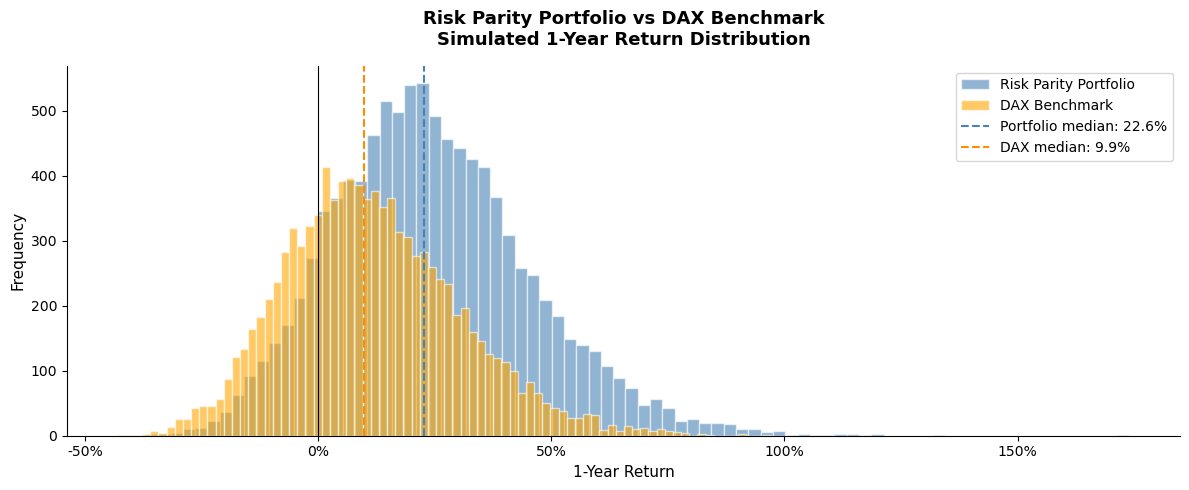


Portfolio vs DAX – Median 1Y Return:
  Risk Parity Portfolio: 22.56%
  DAX Benchmark:         9.86%

Portfolio vs DAX – Probability of Loss:
  Risk Parity Portfolio: 11.7%
  DAX Benchmark:         28.3%


In [6]:
# Compare our optimized portfolio against DAX index
dax_returns = np.log(dax_raw / dax_raw.shift(1)).dropna()
dax_mean    = dax_returns.mean()
dax_std     = dax_returns.std()

# Simulate DAX with same methodology
dax_sims = np.zeros((n_days, n_simulations))
for i in range(n_simulations):
    shocks = np.random.normal(dax_mean, dax_std, n_days)
    dax_sims[:, i] = np.cumprod(1 + shocks)

dax_final  = dax_sims[-1, :]
port_final = final_values

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(port_final - 1, bins=80, alpha=0.6,
        color='steelblue', label='Risk Parity Portfolio', edgecolor='white')
ax.hist(dax_final - 1,  bins=80, alpha=0.6,
        color='orange',   label='DAX Benchmark',          edgecolor='white')

ax.axvline(np.median(port_final - 1), color='steelblue',
           linewidth=1.5, linestyle='--',
           label=f'Portfolio median: {np.median(port_final - 1):.1%}')
ax.axvline(np.median(dax_final - 1), color='darkorange',
           linewidth=1.5, linestyle='--',
           label=f'DAX median: {np.median(dax_final - 1):.1%}')
ax.axvline(0, color='black', linewidth=0.8)

ax.set_title(
    'Risk Parity Portfolio vs DAX Benchmark\n'
    'Simulated 1-Year Return Distribution',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('1-Year Return', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/03_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPortfolio vs DAX – Median 1Y Return:")
print(f"  Risk Parity Portfolio: {np.median(port_final - 1):.2%}")
print(f"  DAX Benchmark:         {np.median(dax_final - 1):.2%}")
print(f"\nPortfolio vs DAX – Probability of Loss:")
print(f"  Risk Parity Portfolio: {(port_final < 1.0).mean():.1%}")
print(f"  DAX Benchmark:         {(dax_final < 1.0).mean():.1%}")